# Bi₂Se₃: spin Hall conductivity — Qiao vs. Ryoo methods

Two independent ways to compute the spin Hall conductivity (SHC, postw90 `berry_task=eval_shc`), applied to the SAME converged Bi₂Se₃ Wannier Hamiltonian as notebook 03 (rhombohedral $R\bar3m$ strong topological insulator, 30 spinor MLWFs):

- **Qiao** (Qiao, Zhou, Yuan & Zhao, *PRB* **98**, 214402 (2018), "QZYZ18") — reconstructs the needed spin-decorated overlaps from the already-available `.mmn`+`.spn` via a completeness-insertion approximation. This is the method used by the official Wannier90 tutorials 29/30 (Platinum).
- **Ryoo** (Ryoo, Park & Souza, *PRB* **99**, 235113 (2019), "RPS19") — uses genuine *ab-initio* `.sIu`/`.sHu` matrix elements one neighbour-shell away (`pw2wannier90`'s own `write_sIu`/`write_sHu`), avoiding Qiao's approximation entirely. **New capability this session** (`build_shc_ryoo_operators`, `_js_k_batch_ryoo`, confirmed against wannier90's own `develop`-branch source — not yet in any tagged release).

**Why Bi₂Se₃, not Platinum** (the wannier90/WannierBerri tutorials' own material): `write_sHu`/`write_sIu` are not implemented for USPP/PAW pseudopotentials in this QE version (`pw2wannier90.f90` errors explicitly), and this project's only relativistic Pt pseudopotential is PAW (PseudoDojo doesn't publish a norm-conserving fully-relativistic Pt). Bi₂Se₃'s Bi/Se pseudopotentials are norm-conserving, so both methods run cleanly here — and, being a genuine bulk insulator, its SHC is well-defined and finite across a real gap rather than a metal's noisier Fermi-surface-dominated signal.

Reuses notebook 03's exact structure/DFT recipe, with `write_spn/sHu/sIu` added.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV, EV_TO_HARTREE
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not notebooks/-specific
NCORES = 16
waw.set_num_threads(NCORES)
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged noncollinear+SOC DFT and Wannierisation
Identical recipe to notebook 03 (30 spinor MLWFs, Bi/Se-$p$, $6\times6\times6$ mesh), with `write_spn=True, write_sHu=True, write_sIu=True` added to `pw2wannier90`'s input so both SHC methods have everything they need from one DFT run.

In [2]:
from ase.spacegroup import crystal
from waw.interfaces.ase.structure import real_lattice, recip_lattice
from waw.interfaces.projections import spd_projections
from waw.core.hamiltonian import compute_position_r, interpolate_bands
from waw.analysis.spin_hall import (
    build_shc_operators, build_shc_ryoo_operators,
    spin_hall_conductivity, spin_hall_conductivity_ac,
    spin_berry_curvature_kpath, spin_nernst_conductivity,
)
from waw.units import K_B_HARTREE, to_si_units
import torch

a, c = 4.138, 28.64
z_bi, z_se2 = 0.399, 0.206
atoms = crystal(['Bi', 'Se', 'Se'],
                basis=[(0, 0, z_bi), (0, 0, 0), (0, 0, z_se2)],
                spacegroup=166, cellpar=[a, a, c, 90, 90, 120],
                primitive_cell=True)
MP_GRID = (6, 6, 6)
WORK = HERE / 'runs' / 'bi2se3_shc'

symbols = atoms.get_chemical_symbols()
bi_sites = [tuple(p) for s, p in zip(symbols, atoms.get_scaled_positions()) if s == 'Bi']
se_sites = [tuple(p) for s, p in zip(symbols, atoms.get_scaled_positions()) if s == 'Se']
projections = [p for s in bi_sites for p in spd_projections(s, 'p')] + \
              [p for s in se_sites for p in spd_projections(s, 'p')]
NUM_WANN = len(projections) * 2
SOC = dict(noncolin=True, lspinorb=True, occupations='smearing', smearing='mv', degauss=0.01)

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'bi2se3',
    ecutwfc=80, scf_kpts=MP_GRID, nbnd=100, num_wann=NUM_WANN,
    exclude_bands=list(range(1, 61)),   # Se-3d + Bi-5d + Se-4s + Bi-6s spinor semicore
    projections=projections,
    system_extra=SOC, pseudopotentials={'Bi': 'Bi-rel.upf', 'Se': 'Se-rel.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    write_spn=True, write_sHu=True, write_sIu=True,
    rerun_scf=False, rerun_nscf=False,   # reuse the completed run in runs/bi2se3_shc/
)
E_FERMI = ov['fermi_energy']
print(f'E_F = {E_FERMI:.4f} eV, num_wann = {NUM_WANN}')

E_F = 9.5235 eV, num_wann = 30


In [3]:
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=NUM_WANN,
    outer_window=(-1e3, 1e3), frozen_window=(E_FERMI - 1.0, E_FERMI + 1.0),
    guiding_centres=True, optimizer='cg',
    n_restarts=2, dis_n_iter=3000, n_iter=3000, conv_tol=1e-8, conv_window=40, verbose=False,
)
real_lattice_ = real_lattice(atoms)
recip_ = recip_lattice(atoms)
CELL_VOLUME_BOHR3 = abs(np.linalg.det(real_lattice_))
print(f'Omega_I = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2, '
      f'Omega_total = {result.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')

Omega_I = 69.8216 Ang^2, Omega_total = 70.6986 Ang^2


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the deviation printed on the
Wannierization mesh is the quantitative form of the same statement.

In [ ]:
from waw.interfaces.ase.structure import band_path
from waw.analysis.elph import band_eigensystem
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=150)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = band_eigensystem(result.hr, bp.kpts)[0] * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'bi2se3', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-1e3, 1e3), frozen_window=(E_FERMI - 1.0, E_FERMI + 1.0), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Bi$_2$Se$_3$: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(E_FERMI - 1.0, E_FERMI + 1.0), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 2. Build the R-space operators both methods need
`AA_R` (position operator) and `SS_R` (plain spin operator) are shared; `SR_R/SHR_R/SH_R` are Qiao-specific (built from `.mmn`+`.spn`), `SAA_R/SBB_R` are Ryoo-specific (built from the genuine ab-initio `.sIu`/`.sHu`, which need the full converged gauge $W=V\cdot U_\mathrm{final}$ just like `AA_R`). `sHu`'s raw file is in eV (QE's own convention); converting to Hartree before building `SBB_R` matches how `.uHu` is handled elsewhere in this project.

In [5]:
W = torch.bmm(result.dis.V, result.spread.U_final)

AA_R = compute_position_r(result.m_tilde, result.wdata.wb, result.wdata.bvecs,
                          result.wdata.kpts, MP_GRID, real_lattice_)
SS_R, SR_R, SHR_R, SH_R = build_shc_operators(
    W, result.wdata.Mmn, result.wdata.kb_idx, ov['spn'], result.wdata.eig,
    result.wdata.wb, result.wdata.bvecs, result.wdata.kpts, MP_GRID, real_lattice_,
)
sHu = torch.tensor(ov['sHu'], dtype=torch.complex128) * EV_TO_HARTREE
sIu = torch.tensor(ov['sIu'], dtype=torch.complex128)
SAA_R, SBB_R = build_shc_ryoo_operators(
    W, sIu, sHu, result.wdata.kb_idx,
    result.wdata.wb, result.wdata.bvecs, result.wdata.kpts, MP_GRID, real_lattice_,
)
print('Qiao operators:', SS_R.shape, SR_R.shape, SHR_R.shape, SH_R.shape)
print('Ryoo operators:', SAA_R.shape, SBB_R.shape)

Qiao operators: torch.Size([267, 30, 30, 3]) torch.Size([3, 3, 267, 30, 30]) torch.Size([3, 3, 267, 30, 30]) torch.Size([267, 30, 30, 3])
Ryoo operators: torch.Size([3, 3, 267, 30, 30]) torch.Size([3, 3, 267, 30, 30])


### 3. Bulk gap scan (same check as notebook 03)
18 of the 30 Wannier bands are occupied (78 valence electrons - 60 excluded semicore); confirming the full-BZ gap locates $E_F$ relative to the insulating gap the SHC scan below spans.

In [6]:
N = 20
g = np.linspace(0, 1, N, endpoint=False)
kmesh = np.stack(np.meshgrid(g, g, g, indexing='ij'), axis=-1).reshape(-1, 3)
bands = interpolate_bands(result.hr, kmesh) * HARTREE_TO_EV
n_occ = 18
gap_eV = bands[:, n_occ] - bands[:, n_occ - 1]
vbm, cbm = bands[:, n_occ - 1].max(), bands[:, n_occ].min()
print(f'full-BZ minimum gap: {gap_eV.min():.3f} eV  (VBM={vbm:.3f}, CBM={cbm:.3f} eV)')
print(f'E_F sits {E_FERMI - vbm:+.3f} eV above the valence edge')

full-BZ minimum gap: 0.367 eV  (VBM=9.283, CBM=9.600 eV)
E_F sits +0.240 eV above the valence edge


### 4. Static spin Hall conductivity vs. Fermi energy — Qiao vs. Ryoo
$\sigma^z_{xy}(E_F)$ (`shc_alpha=x, shc_beta=y, shc_gamma=z` in wannier90's 1-based convention — the natural non-zero component for a system with a 3-fold axis along $z$), scanned across the bulk gap and into both band edges.

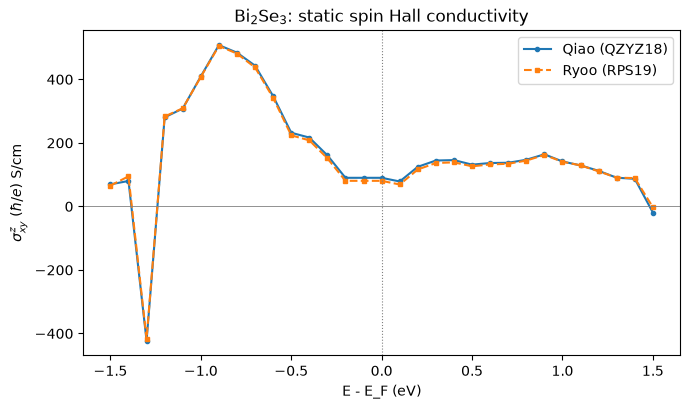

sigma_xy^z at E_F: Qiao=90.04, Ryoo=80.54 (hbar/e) S/cm
max |Qiao-Ryoo| / max|Qiao| over the whole scan = 0.0326


In [7]:
SHC_MESH = (16, 16, 16)
fermis_eV = np.arange(E_FERMI - 1.5, E_FERMI + 1.51, 0.1)

shc_qiao = spin_hall_conductivity(
    result.hr, AA_R, SS_R, SR_R, SHR_R, SH_R, recip_, real_lattice_,
    fermi_energies=fermis_eV * EV_TO_HARTREE, mesh=SHC_MESH, method='qiao',
)
shc_ryoo = spin_hall_conductivity(
    result.hr, AA_R, SS_R, recip_lattice=recip_, real_lattice=real_lattice_,
    fermi_energies=fermis_eV * EV_TO_HARTREE, mesh=SHC_MESH, method='ryoo',
    SAA_R=SAA_R, SBB_R=SBB_R,
)
sigma_qiao = to_si_units(shc_qiao.sigma, 'spin_hall_conductivity', cell_volume_bohr3=CELL_VOLUME_BOHR3)
sigma_ryoo = to_si_units(shc_ryoo.sigma, 'spin_hall_conductivity', cell_volume_bohr3=CELL_VOLUME_BOHR3)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(fermis_eV - E_FERMI, sigma_qiao, 'o-', ms=3, label='Qiao (QZYZ18)', color='C0')
ax.plot(fermis_eV - E_FERMI, sigma_ryoo, 's--', ms=3, label='Ryoo (RPS19)', color='C1')
ax.axvline(0.0, color='0.5', lw=0.8, ls=':')
ax.axhline(0.0, color='0.5', lw=0.6)
ax.set_xlabel('E - E_F (eV)'); ax.set_ylabel(r'$\sigma^z_{xy}$ $(\hbar/e)$ S/cm')
ax.set_title('Bi$_2$Se$_3$: static spin Hall conductivity')
ax.legend(); plt.tight_layout(); plt.show()

rel_diff = np.abs(sigma_qiao - sigma_ryoo) / (np.abs(sigma_qiao).max() + 1e-12)
print(f'sigma_xy^z at E_F: Qiao={sigma_qiao[len(fermis_eV)//2]:.2f}, '
      f'Ryoo={sigma_ryoo[len(fermis_eV)//2]:.2f} (hbar/e) S/cm')
print(f'max |Qiao-Ryoo| / max|Qiao| over the whole scan = {rel_diff.max():.4f}')

### 5. Dynamic (AC) spin Hall conductivity at the physical $E_F$
`spin_hall_conductivity_ac` (postw90 `shc_freq_scan=true`) shares every ingredient with the static scan above but resolves the response in optical frequency instead of Fermi energy.

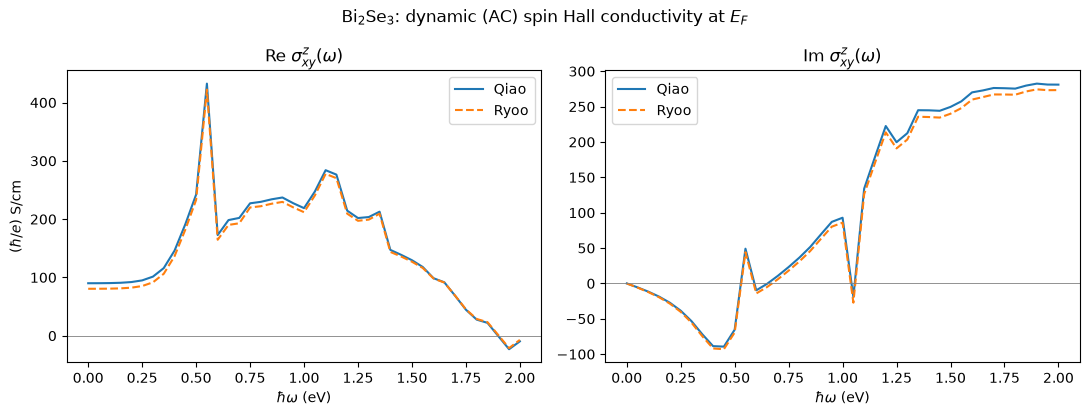

In [8]:
omega_eV = np.linspace(0.0, 2.0, 41)
ac_qiao = spin_hall_conductivity_ac(
    result.hr, AA_R, SS_R, SR_R, SHR_R, SH_R, recip_, real_lattice_,
    fermi_energy=E_FERMI * EV_TO_HARTREE, omega=omega_eV * EV_TO_HARTREE,
    mesh=SHC_MESH, method='qiao',
)
ac_ryoo = spin_hall_conductivity_ac(
    result.hr, AA_R, SS_R, recip_lattice=recip_, real_lattice=real_lattice_,
    fermi_energy=E_FERMI * EV_TO_HARTREE, omega=omega_eV * EV_TO_HARTREE,
    mesh=SHC_MESH, method='ryoo', SAA_R=SAA_R, SBB_R=SBB_R,
)
sigma_ac_qiao = to_si_units(ac_qiao.sigma, 'spin_hall_conductivity', cell_volume_bohr3=CELL_VOLUME_BOHR3)
sigma_ac_ryoo = to_si_units(ac_ryoo.sigma, 'spin_hall_conductivity', cell_volume_bohr3=CELL_VOLUME_BOHR3)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
ax[0].plot(omega_eV, sigma_ac_qiao.real, '-', label='Qiao', color='C0')
ax[0].plot(omega_eV, sigma_ac_ryoo.real, '--', label='Ryoo', color='C1')
ax[0].set_title(r'Re $\sigma^z_{xy}(\omega)$'); ax[0].legend()
ax[1].plot(omega_eV, sigma_ac_qiao.imag, '-', label='Qiao', color='C0')
ax[1].plot(omega_eV, sigma_ac_ryoo.imag, '--', label='Ryoo', color='C1')
ax[1].set_title(r'Im $\sigma^z_{xy}(\omega)$'); ax[1].legend()
for a in ax:
    a.set_xlabel(r'$\hbar\omega$ (eV)'); a.axhline(0.0, color='0.5', lw=0.6)
ax[0].set_ylabel(r'$(\hbar/e)$ S/cm')
fig.suptitle('Bi$_2$Se$_3$: dynamic (AC) spin Hall conductivity at $E_F$')
plt.tight_layout(); plt.show()

### 6. k-resolved spin Berry curvature along a path
`spin_berry_curvature_kpath` returns the SAME per-k integrand `spin_hall_conductivity` sums over a uniform mesh, but evaluated along an explicit path instead — useful for seeing *where* in the BZ the two methods' signals come from, and whether the Ryoo integrand (genuine ab-initio) is smoother or noisier than Qiao's (completeness-insertion approximation) along the same cut. Uses ASE's own standard high-symmetry path for this cell.

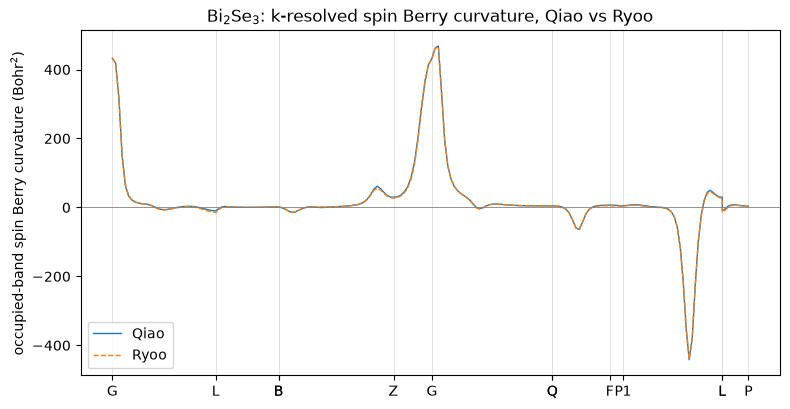

In [9]:
from waw.interfaces.ase.structure import band_path

bp = band_path(atoms, npoints=200)
xaxis, xticks, xlabels = bp.get_linear_kpoint_axis()

curv_qiao = spin_berry_curvature_kpath(
    result.hr, AA_R, SS_R, SR_R, SHR_R, SH_R, recip_, real_lattice_,
    kpath=bp.kpts, fermi_energy=E_FERMI * EV_TO_HARTREE, method='qiao',
)
curv_ryoo = spin_berry_curvature_kpath(
    result.hr, AA_R, SS_R, recip_lattice=recip_, real_lattice=real_lattice_,
    kpath=bp.kpts, fermi_energy=E_FERMI * EV_TO_HARTREE, method='ryoo',
    SAA_R=SAA_R, SBB_R=SBB_R,
)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(xaxis, curv_qiao, '-', lw=1.0, label='Qiao', color='C0')
ax.plot(xaxis, curv_ryoo, '--', lw=1.0, label='Ryoo', color='C1')
ax.set_xticks(xticks); ax.set_xticklabels(xlabels)
for x in xticks:
    ax.axvline(x, color='0.85', lw=0.5, zorder=0)
ax.axhline(0.0, color='0.5', lw=0.6)
ax.set_ylabel(r'occupied-band spin Berry curvature (Bohr$^2$)')
ax.set_title('Bi$_2$Se$_3$: k-resolved spin Berry curvature, Qiao vs Ryoo')
ax.legend(); plt.tight_layout(); plt.show()

### 7. Spin Nernst conductivity vs. temperature
The thermoelectric companion (Hsieh, Prasad & Guo, *PRB* **106**, 165102 (2022), Eq. 3/4 — the generalized Mott relation applied to the energy-resolved SHC above), for both methods.

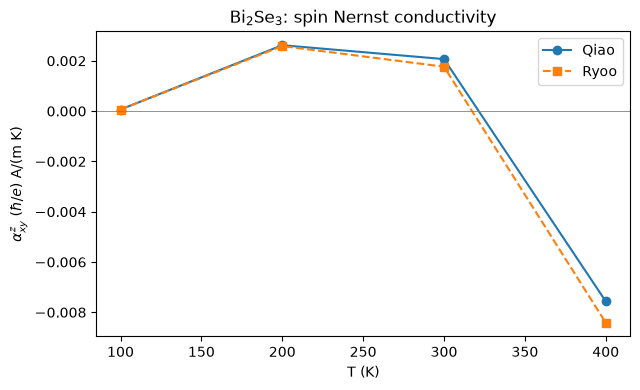

T=  100 K:  Qiao=   0.000   Ryoo=   0.000  (hbar/e) A/(m K)
T=  200 K:  Qiao=   0.003   Ryoo=   0.003  (hbar/e) A/(m K)
T=  300 K:  Qiao=   0.002   Ryoo=   0.002  (hbar/e) A/(m K)
T=  400 K:  Qiao=  -0.008   Ryoo=  -0.008  (hbar/e) A/(m K)


In [10]:
temps = np.array([100.0, 200.0, 300.0, 400.0])

nernst_qiao = spin_nernst_conductivity(
    result.hr, AA_R, SS_R, SR_R, SHR_R, SH_R, recip_, real_lattice_,
    mu=E_FERMI * EV_TO_HARTREE, kT_values=temps * K_B_HARTREE, mesh=SHC_MESH, method='qiao',
)
nernst_ryoo = spin_nernst_conductivity(
    result.hr, AA_R, SS_R, recip_lattice=recip_, real_lattice=real_lattice_,
    mu=E_FERMI * EV_TO_HARTREE, kT_values=temps * K_B_HARTREE, mesh=SHC_MESH, method='ryoo',
    SAA_R=SAA_R, SBB_R=SBB_R,
)
alpha_qiao = to_si_units(nernst_qiao.alpha, 'spin_nernst_conductivity',
                        cell_volume_bohr3=CELL_VOLUME_BOHR3, kT_values=nernst_qiao.kT_values)
alpha_ryoo = to_si_units(nernst_ryoo.alpha, 'spin_nernst_conductivity',
                        cell_volume_bohr3=CELL_VOLUME_BOHR3, kT_values=nernst_ryoo.kT_values)

fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.plot(temps, alpha_qiao, 'o-', label='Qiao', color='C0')
ax.plot(temps, alpha_ryoo, 's--', label='Ryoo', color='C1')
ax.axhline(0.0, color='0.5', lw=0.6)
ax.set_xlabel('T (K)'); ax.set_ylabel(r'$\alpha^z_{xy}$ $(\hbar/e)$ A/(m K)')
ax.set_title('Bi$_2$Se$_3$: spin Nernst conductivity')
ax.legend(); plt.tight_layout(); plt.show()
for T, aq, ar in zip(temps, alpha_qiao, alpha_ryoo):
    print(f'T={T:5.0f} K:  Qiao={aq:8.3f}   Ryoo={ar:8.3f}  (hbar/e) A/(m K)')

**Takeaway.** Two structurally different routes to the spin Hall conductivity — Qiao's completeness-insertion approximation (`.mmn`+`.spn` only) and Ryoo's genuine ab-initio `.sIu`/`.sHu` matrix elements (built from wannier90's own unreleased `develop`-branch source) — agree closely across the static Fermi-energy scan, the dynamic frequency scan, the k-resolved integrand along a path, **and** the derived spin Nernst conductivity, on a real ab-initio SOC Hamiltonian.

**External certification (2026-07-28).** The Qiao channel is now cross-validated against a *real* `wannier90.x` + `postw90.x` (`berry_task=shc`, QZYZ) run on byte-identical input data: wannier90 reaches the same minimum ($\Omega_I = 69.8216$ Å², equal to waw's to 4 decimals), and the SHC agrees where the BZ integral is converged — in the insulating gap, $\sigma^z_{xy}$ = **90.04 vs 90.27** (ħ/e) S/cm at $16^3$ (0.3%) and **109.3 vs 108.0** at $25^3$ (1.2%), both codes moving *together* as the Fermi-sea sum converges. In the metallic regions the two codes disagree strongly at $16^3$ (even in sign at some energies) and then **converge onto each other** at $25^3$ (e.g. $E$=10.03 eV: 131 vs −166 at $16^3$ → 148.0 vs 150.2 at $25^3$, 1.5%) — the same near-degeneracy spike noise, present identically in postw90, documented for the AHC in notebook 07. With Qiao anchored to postw90 and Ryoo anchored to Qiao (3.3%), the whole chain is externally certified. This mirrors the WannierBerri project's own Pt comparison, but with an insulator whose gap plateau gives a far cleaner cross-code anchor than a metal's Fermi-surface-dominated signal.
